Cargando dataset...

--- Primeras 5 filas ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


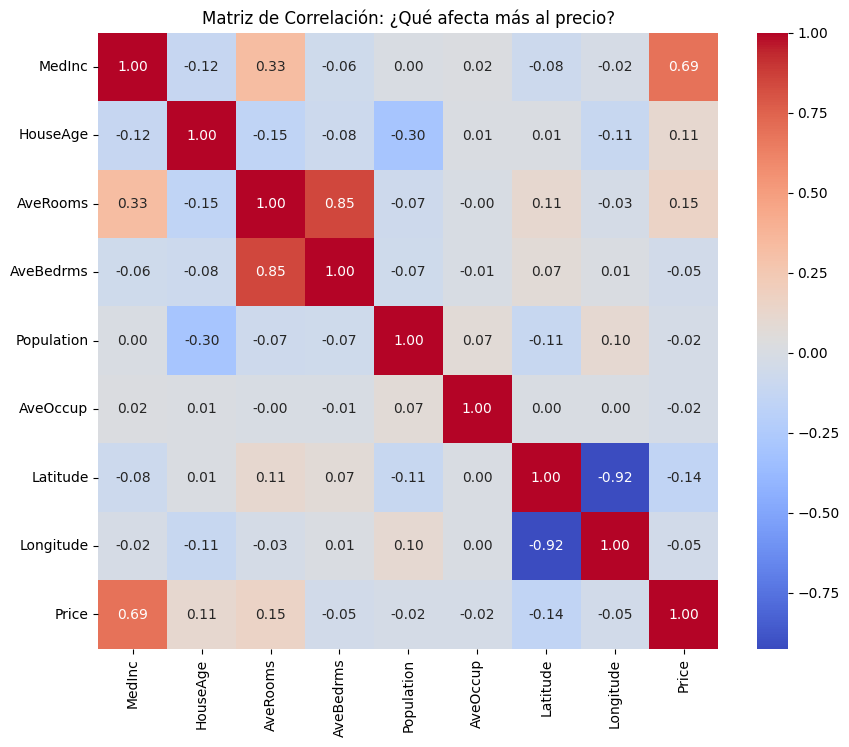


Entrenando modelo de Regresión Lineal...

--- Resultados de Evaluación ---
Mean Squared Error (MSE): 0.5559
R-squared (R2 Score): 0.5758
Interpretación: Un R2 de 1.0 es perfecto. Un R2 de 0.60 es decente para datos reales.


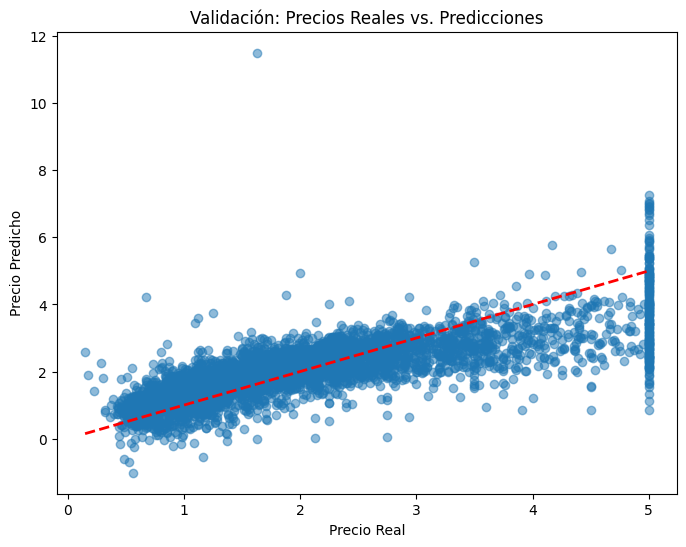

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. DATA ENGINEERING & EDA (Análisis Exploratorio) ---
print("Cargando dataset...")
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target # El precio es nuestra variable objetivo (Target)

# Vistazo rápido a los datos
print("\n--- Primeras 5 filas ---")
print(df.head())

# Análisis de Correlación (Para identificar 'Key Market Drivers')
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación: ¿Qué afecta más al precio?")
plt.show()

# --- 2. PREPROCESAMIENTO ---
# Definimos Features (X) y Target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# División Train/Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Crucial para modelos de regresión)
# Estandarizamos para que características grandes (como el ingreso total)
# no dominen a las pequeñas (como número de habitaciones).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. PREDICTIVE MODELING ---
print("\nEntrenando modelo de Regresión Lineal...")
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Hacemos predicciones
y_pred = model.predict(X_test_scaled)

# --- 4. PERFORMANCE EVALUATION ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Resultados de Evaluación ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")
print("Interpretación: Un R2 de 1.0 es perfecto. Un R2 de 0.60 es decente para datos reales.")

# Visualización: Realidad vs. Predicción
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Línea de perfección
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Validación: Precios Reales vs. Predicciones")
plt.show()

In [2]:
import ipywidgets as widgets
from IPython.display import display

print("🏠 SIMULADOR DE PRECIOS DE CALIFORNIA 🏠")
print("Mueve los sliders para cambiar las características:")

# Función que se ejecutará cada vez que muevas un slider
def predecir_interactivo(Ingreso, Edad, Cuartos, Dormitorios, Poblacion, Ocupacion, Latitud, Longitud):

    # 1. Creamos el array con tus inputs
    # Nota: El ingreso en el slider está en "decenas de miles", igual que el dataset
    entrada = np.array([[Ingreso, Edad, Cuartos, Dormitorios, Poblacion, Ocupacion, Latitud, Longitud]])

    # 2. Escalamos (¡CRUCIAL! Usamos el mismo scaler del entrenamiento)
    entrada_escalada = scaler.transform(entrada)

    # 3. Predecimos
    prediccion = model.predict(entrada_escalada)
    precio = prediccion[0] * 100000 # Convertir a dólares reales

    # 4. Mostramos el resultado con formato bonito
    print(f"\n💎 VALOR ESTIMADO: ${precio:,.2f} USD")

# Creamos la interfaz gráfica automática
widgets.interact(predecir_interactivo,
                 Ingreso=widgets.FloatSlider(min=0.5, max=15.0, step=0.1, value=5.0, description='Ingreso (10k)'),
                 Edad=widgets.IntSlider(min=1, max=52, step=1, value=20, description='Antigüedad'),
                 Cuartos=widgets.FloatSlider(min=1, max=10, step=0.1, value=5.0, description='Cuartos Prom'),
                 Dormitorios=widgets.FloatSlider(min=0.5, max=5, step=0.1, value=1.0, description='Dormitorios'),
                 Poblacion=widgets.IntSlider(min=100, max=5000, step=50, value=1000, description='Población'),
                 Ocupacion=widgets.FloatSlider(min=1.0, max=6.0, step=0.1, value=3.0, description='Pers/Casa'),
                 Latitud=widgets.FloatSlider(min=32.5, max=42.0, step=0.1, value=34.0, description='Latitud'),
                 Longitud=widgets.FloatSlider(min=-124.3, max=-114.3, step=0.1, value=-118.2, description='Longitud'));

🏠 SIMULADOR DE PRECIOS DE CALIFORNIA 🏠
Mueve los sliders para cambiar las características:


interactive(children=(FloatSlider(value=5.0, description='Ingreso (10k)', max=15.0, min=0.5), IntSlider(value=…

/tmp/ipykernel_491/1494460154.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Variable', data=df_importancia, palette='viridis')


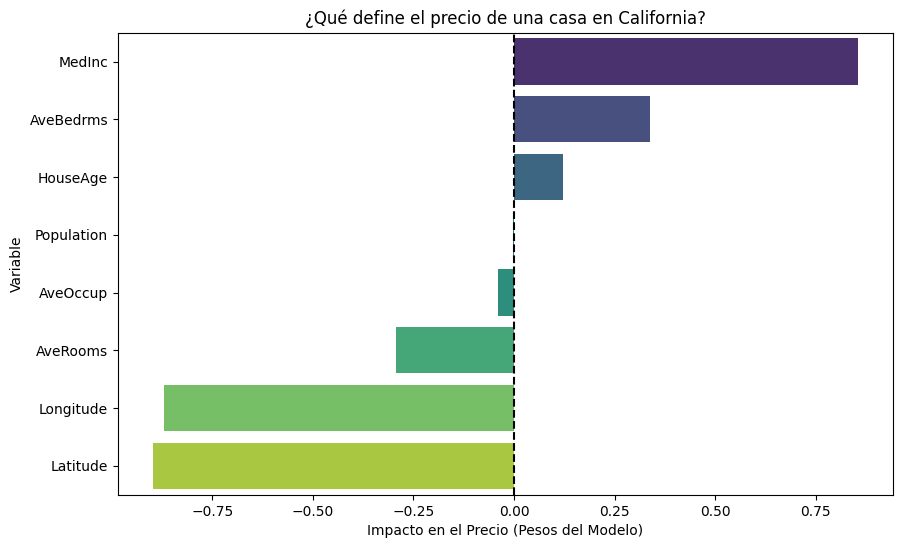

In [3]:
# --- 6. ANÁLISIS DE IMPORTANCIA DE VARIABLES (Feature Importance) ---
# Esto responde a la pregunta: ¿Qué factor influye más en el precio?

# Obtenemos los pesos (coeficientes) que aprendió el modelo
importancia = model.coef_
nombres = housing.feature_names

# Creamos un DataFrame para ordenarlos
df_importancia = pd.DataFrame({'Variable': nombres, 'Peso': importancia})
df_importancia = df_importancia.sort_values(by='Peso', ascending=False)

# Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x='Peso', y='Variable', data=df_importancia, palette='viridis')
plt.title('¿Qué define el precio de una casa en California?')
plt.xlabel('Impacto en el Precio (Pesos del Modelo)')
plt.axvline(x=0, color='black', linestyle='--') # Línea de cero
plt.show()